In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score, accuracy_score)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

In [7]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (6362620, 11)

First few rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Basic information
print("\n1. Dataset Info:")
print(df.info())

print("\n2. Statistical Summary:")
print(df.describe())

print("\n3. Missing Values:")
print(df.isnull().sum())

print("\n4. Duplicate Rows:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Check class distribution
print("\n5. CLASS DISTRIBUTION (Target Variable):")
print(df['isFraud'].value_counts())
print("\nPercentage distribution:")
print(df['isFraud'].value_counts(normalize=True) * 100)

fraud_percentage = (df['isFraud'].sum() / len(df)) * 100
print(f"\nFraud Rate: {fraud_percentage:.4f}%")
print(f"This is highly imbalanced! Only {fraud_percentage:.4f}% are fraudulent.")

# Transaction type distribution
print("\n6. Transaction Type Distribution:")
print(df['type'].value_counts())

# Fraud by transaction type
print("\n7. Fraud Cases by Transaction Type:")
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
print(fraud_by_type)
print("\nImportant: Fraud only occurs in CASH_OUT and TRANSFER transactions!")


EXPLORATORY DATA ANALYSIS

1. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

2. Statistical Summary:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+


DATA VISUALIZATION


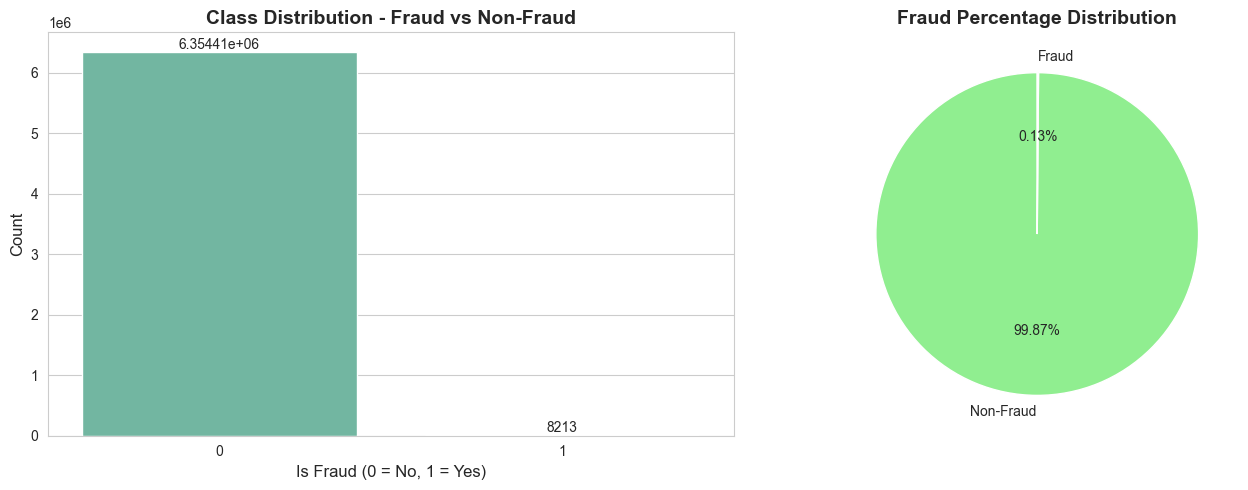

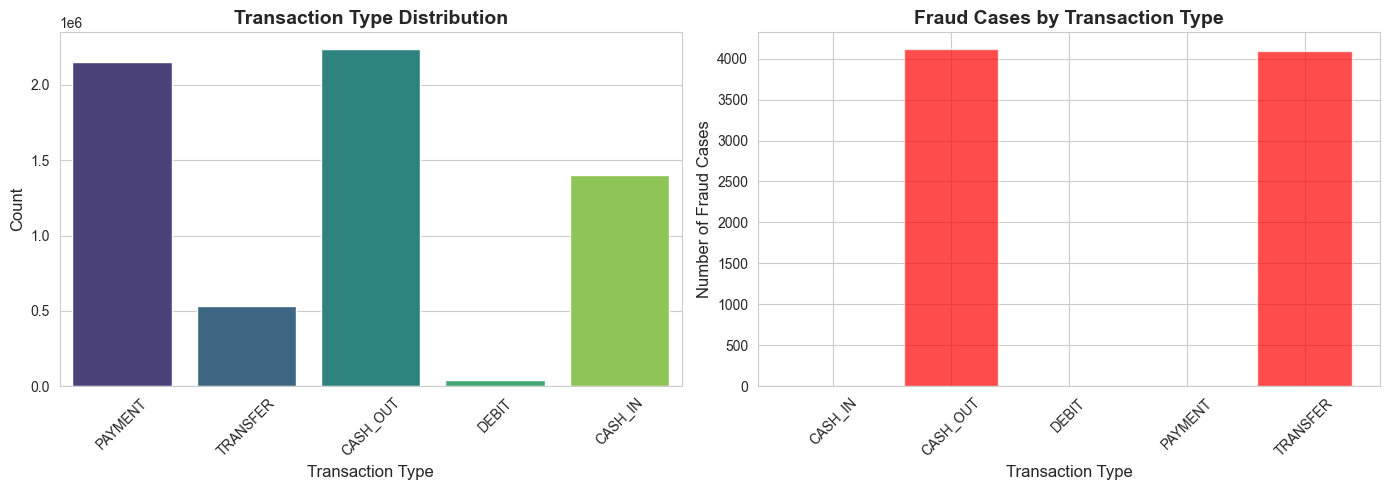

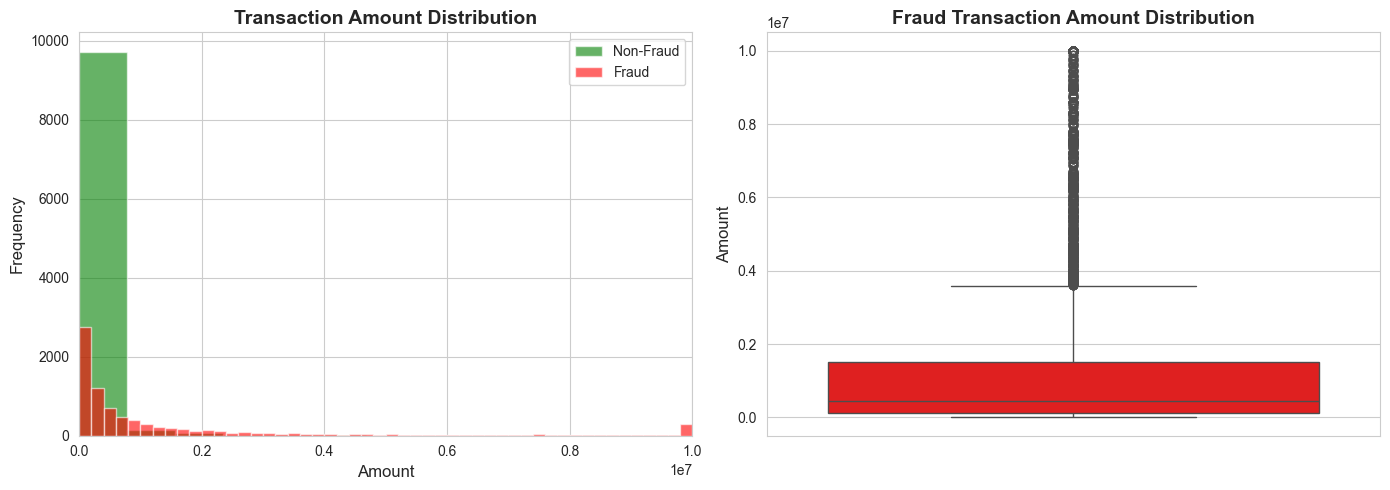


8. Correlation Analysis:


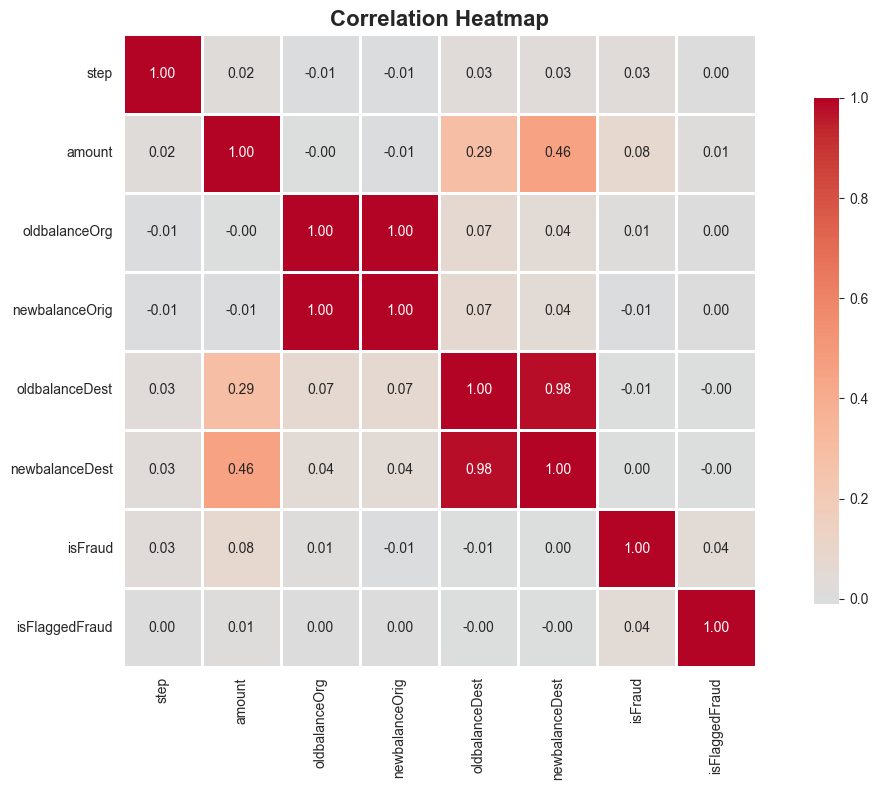

In [9]:
print("\n" + "="*80)
print("DATA VISUALIZATION")
print("="*80)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='isFraud', ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution - Fraud vs Non-Fraud', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Fraud (0 = No, 1 = Yes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
fraud_counts = df['isFraud'].value_counts()
axes[1].pie(fraud_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%',
            startangle=90, colors=['#90EE90', '#FF6B6B'])
axes[1].set_title('Fraud Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Transaction Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type counts
sns.countplot(data=df, x='type', ax=axes[0], palette='viridis')
axes[0].set_title('Transaction Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Fraud by transaction type
fraud_type = df.groupby('type')['isFraud'].sum()
axes[1].bar(fraud_type.index, fraud_type.values, color='red', alpha=0.7)
axes[1].set_title('Fraud Cases by Transaction Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Type', fontsize=12)
axes[1].set_ylabel('Number of Fraud Cases', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution for fraud vs non-fraud
df_fraud = df[df['isFraud'] == 1]
df_non_fraud = df[df['isFraud'] == 0].sample(10000)  # Sample for better visualization

axes[0].hist(df_non_fraud['amount'], bins=50, alpha=0.6, label='Non-Fraud', color='green')
axes[0].hist(df_fraud['amount'], bins=50, alpha=0.6, label='Fraud', color='red')
axes[0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].set_xlim(0, 1e7)

# Box plot
sns.boxplot(data=df[df['isFraud'] == 1], y='amount', ax=axes[1], color='red')
axes[1].set_title('Fraud Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amount', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
print("\n8. Correlation Analysis:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create a copy for feature engineering
df_fe = df.copy()

print("\nCreating new features...")

# 1. Balance difference features
df_fe['origBalanceDiff'] = df_fe['oldbalanceOrg'] - df_fe['newbalanceOrig']
df_fe['destBalanceDiff'] = df_fe['oldbalanceDest'] - df_fe['newbalanceDest']

# 2. Balance error detection (amount should equal balance difference)
df_fe['origBalanceError'] = df_fe['amount'] - df_fe['origBalanceDiff']
df_fe['destBalanceError'] = df_fe['amount'] + df_fe['destBalanceDiff']

# 3. Transaction amount categories
df_fe['amountCategory'] = pd.cut(df_fe['amount'],
                                  bins=[0, 1000, 10000, 100000, 1000000, np.inf],
                                  labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 4. Zero balance flags
df_fe['origBalanceZero'] = (df_fe['oldbalanceOrg'] == 0).astype(int)
df_fe['destBalanceZero'] = (df_fe['oldbalanceDest'] == 0).astype(int)

# 5. Time-based features (step represents hours)
df_fe['day'] = df_fe['step'] // 24
df_fe['hour'] = df_fe['step'] % 24

print("New features created!")
print(f"Total features now: {df_fe.shape[1]}")


FEATURE ENGINEERING

Creating new features...
New features created!
Total features now: 20


In [12]:
# ============================================================================
# STEP 6: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Filter only CASH_OUT and TRANSFER transactions (where fraud occurs)
print("\nFiltering only CASH_OUT and TRANSFER transactions...")
df_filtered = df_fe[df_fe['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Fraud percentage after filtering: {(df_filtered['isFraud'].sum() / len(df_filtered)) * 100:.4f}%")

# Drop unnecessary columns
columns_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'amountCategory']
df_processed = df_filtered.drop(columns=columns_to_drop, errors='ignore')

# Encode transaction type
label_encoder = LabelEncoder()
df_processed['type'] = label_encoder.fit_transform(df_processed['type'])

print("\nEncoded transaction types:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Separate features and target
X = df_processed.drop('isFraud', axis=1)
y = df_processed['isFraud']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution in target:")
print(Counter(y))


DATA PREPROCESSING

Filtering only CASH_OUT and TRANSFER transactions...
Filtered dataset shape: (2770409, 20)
Fraud percentage after filtering: 0.2965%

Encoded transaction types:
{'CASH_OUT': np.int64(0), 'TRANSFER': np.int64(1)}

Features shape: (2770409, 15)
Target shape: (2770409,)

Class distribution in target:
Counter({0: 2762196, 1: 8213})


In [13]:
# ============================================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Split data (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(Counter(y_train))
print(f"\nTest set class distribution:")
print(Counter(y_test))

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


TRAIN-TEST SPLIT
Training set size: (2216327, 15)
Test set size: (554082, 15)

Training set class distribution:
Counter({0: 2209757, 1: 6570})

Test set class distribution:
Counter({0: 552439, 1: 1643})

Feature scaling completed!


In [14]:
# ============================================================================
# STEP 8: HANDLING CLASS IMBALANCE WITH SMOTE
# ============================================================================

print("\n" + "="*80)
print("HANDLING CLASS IMBALANCE")
print("="*80)

print("\nBefore SMOTE:")
print(f"Training set class distribution: {Counter(y_train)}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Balanced training set shape: {X_train_balanced.shape}")
print(f"Balanced class distribution: {Counter(y_train_balanced)}")



HANDLING CLASS IMBALANCE

Before SMOTE:
Training set class distribution: Counter({0: 2209757, 1: 6570})

After SMOTE:
Balanced training set shape: (4419514, 15)
Balanced class distribution: Counter({0: 2209757, 1: 2209757})


In [15]:
# ============================================================================
# STEP 9: MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

# Dictionary to store models and their results
models = {}
results = {}

# 1. Logistic Regression
print("\n1. Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_balanced, y_train_balanced)
models['Logistic Regression'] = lr
print("✓ Logistic Regression trained")

# 2. Decision Tree
print("\n2. Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
dt.fit(X_train_balanced, y_train_balanced)
models['Decision Tree'] = dt
print("✓ Decision Tree trained")

# 3. Random Forest
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15,
                            class_weight='balanced', n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
models['Random Forest'] = rf
print("✓ Random Forest trained")

# 4. XGBoost
print("\n4. Training XGBoost...")
scale_pos_weight = Counter(y_train_balanced)[0] / Counter(y_train_balanced)[1]
xgb = XGBClassifier(random_state=42, n_estimators=100, max_depth=7,
                   scale_pos_weight=scale_pos_weight, learning_rate=0.1,
                   eval_metric='logloss')
xgb.fit(X_train_balanced, y_train_balanced)
models['XGBoost'] = xgb
print("✓ XGBoost trained")

# 5. LightGBM
print("\n5. Training LightGBM...")
lgbm = LGBMClassifier(random_state=42, n_estimators=100, max_depth=7,
                     class_weight='balanced', learning_rate=0.1, verbose=-1)
lgbm.fit(X_train_balanced, y_train_balanced)
models['LightGBM'] = lgbm
print("✓ LightGBM trained")

print("\n✅ All models trained successfully!")


MODEL TRAINING

1. Training Logistic Regression...
✓ Logistic Regression trained

2. Training Decision Tree...
✓ Decision Tree trained

3. Training Random Forest...
✓ Random Forest trained

4. Training XGBoost...
✓ XGBoost trained

5. Training LightGBM...
✓ LightGBM trained

✅ All models trained successfully!


In [16]:
# ============================================================================
# STEP 10: MODEL EVALUATION
# ============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Predictions': y_pred,
        'Probabilities': y_pred_proba
    }

# Evaluate all models
for model_name, model in models.items():
    results[model_name] = evaluate_model(model, X_test_scaled, y_test, model_name)


MODEL EVALUATION

Logistic Regression

Accuracy:  0.9449
Precision: 0.0476
Recall:    0.9245
F1-Score:  0.0905
ROC-AUC:   0.9841

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.94      0.97    552439
       Fraud       0.05      0.92      0.09      1643

    accuracy                           0.94    554082
   macro avg       0.52      0.93      0.53    554082
weighted avg       1.00      0.94      0.97    554082


Confusion Matrix:
[[522016  30423]
 [   124   1519]]

Decision Tree

Accuracy:  0.9996
Precision: 0.8950
Recall:    0.9963
F1-Score:  0.9430
ROC-AUC:   0.9978

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    552439
       Fraud       0.90      1.00      0.94      1643

    accuracy                           1.00    554082
   macro avg       0.95      1.00      0.97    554082
weighted avg       1.00      1.00      1.00    554082


Confusi


MODEL COMPARISON

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
           LightGBM  0.999926   0.979067 0.996348  0.987632 0.998542
      Random Forest  0.999901   0.970379 0.996957  0.983488 0.998645
      Decision Tree  0.999643   0.895025 0.996348  0.942972 0.997781
            XGBoost  0.998695   0.696749 0.991479  0.818387 0.998533
Logistic Regression  0.944869   0.047555 0.924528  0.090457 0.984073


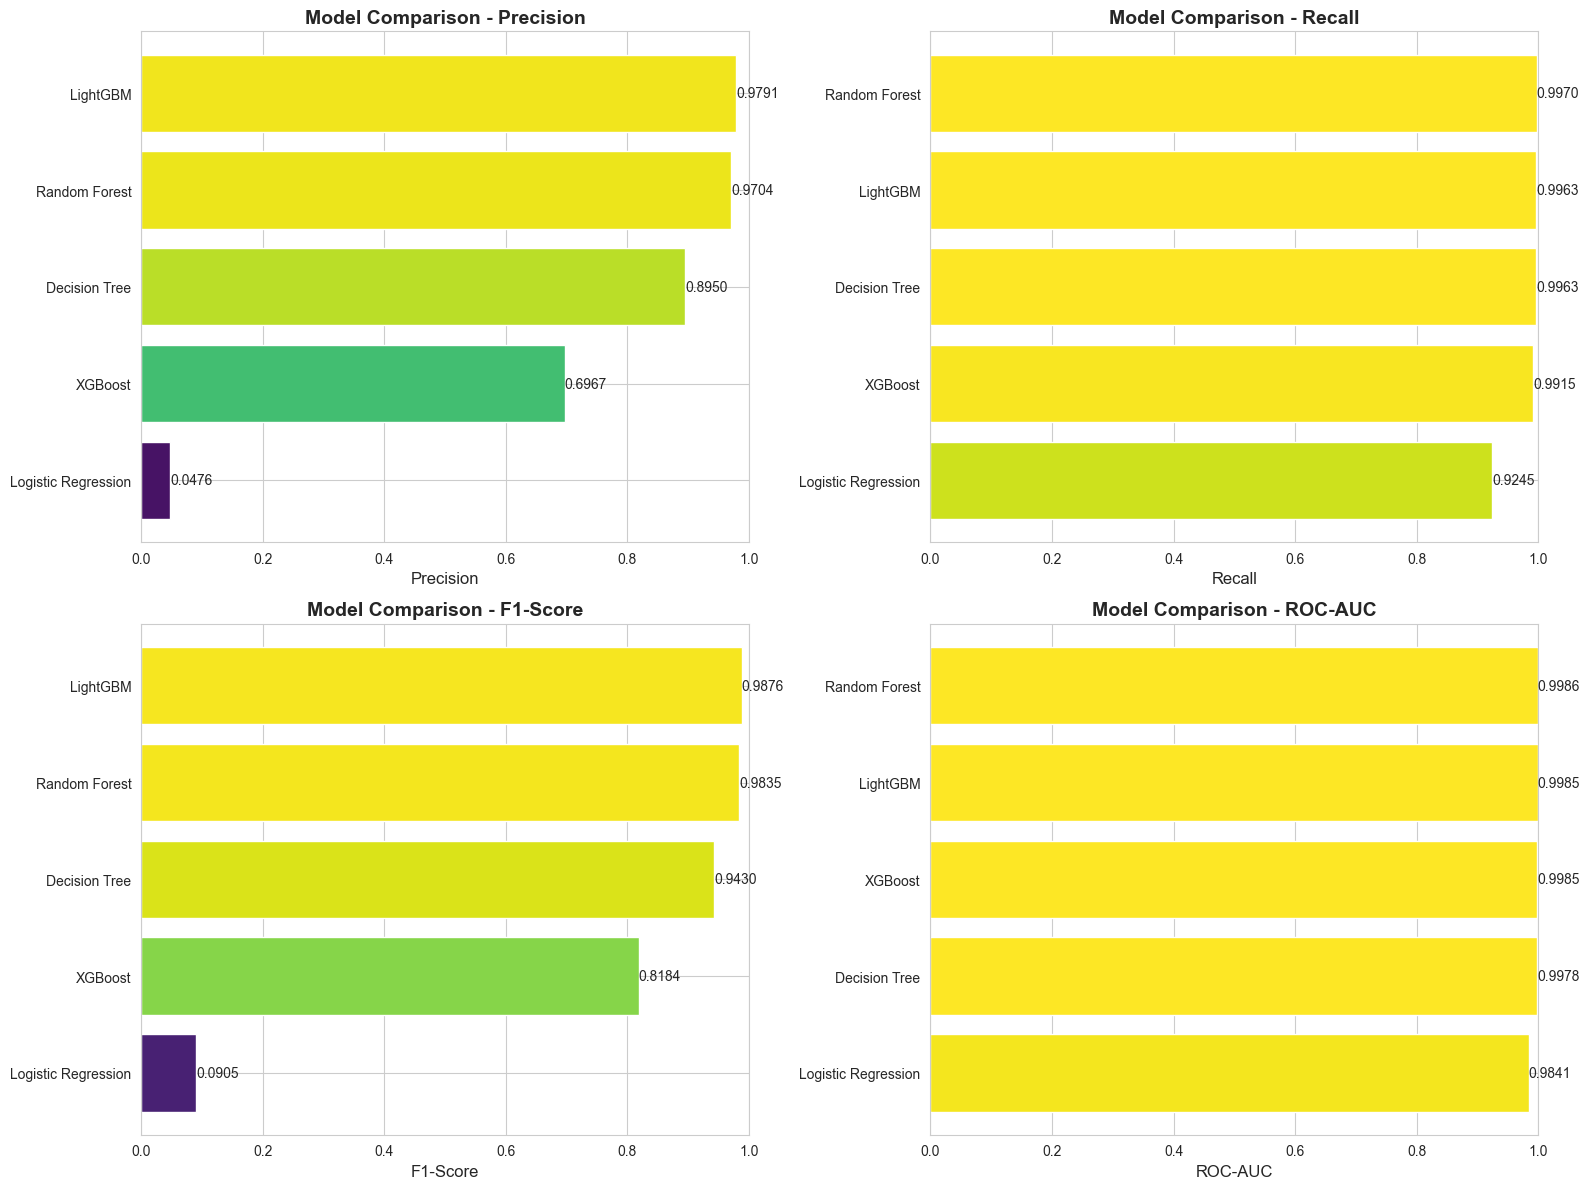

In [18]:
# ============================================================================
# STEP 11: MODEL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()],
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("\n", comparison_df.to_string(index=False))

# Visualization - Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2

    ax = axes[row, col]
    comparison_sorted = comparison_df.sort_values(metric, ascending=True)

    bars = ax.barh(comparison_sorted['Model'], comparison_sorted[metric],
                   color=plt.cm.viridis(comparison_sorted[metric]))
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Model Comparison - {metric}', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()


CONFUSION MATRIX VISUALIZATION


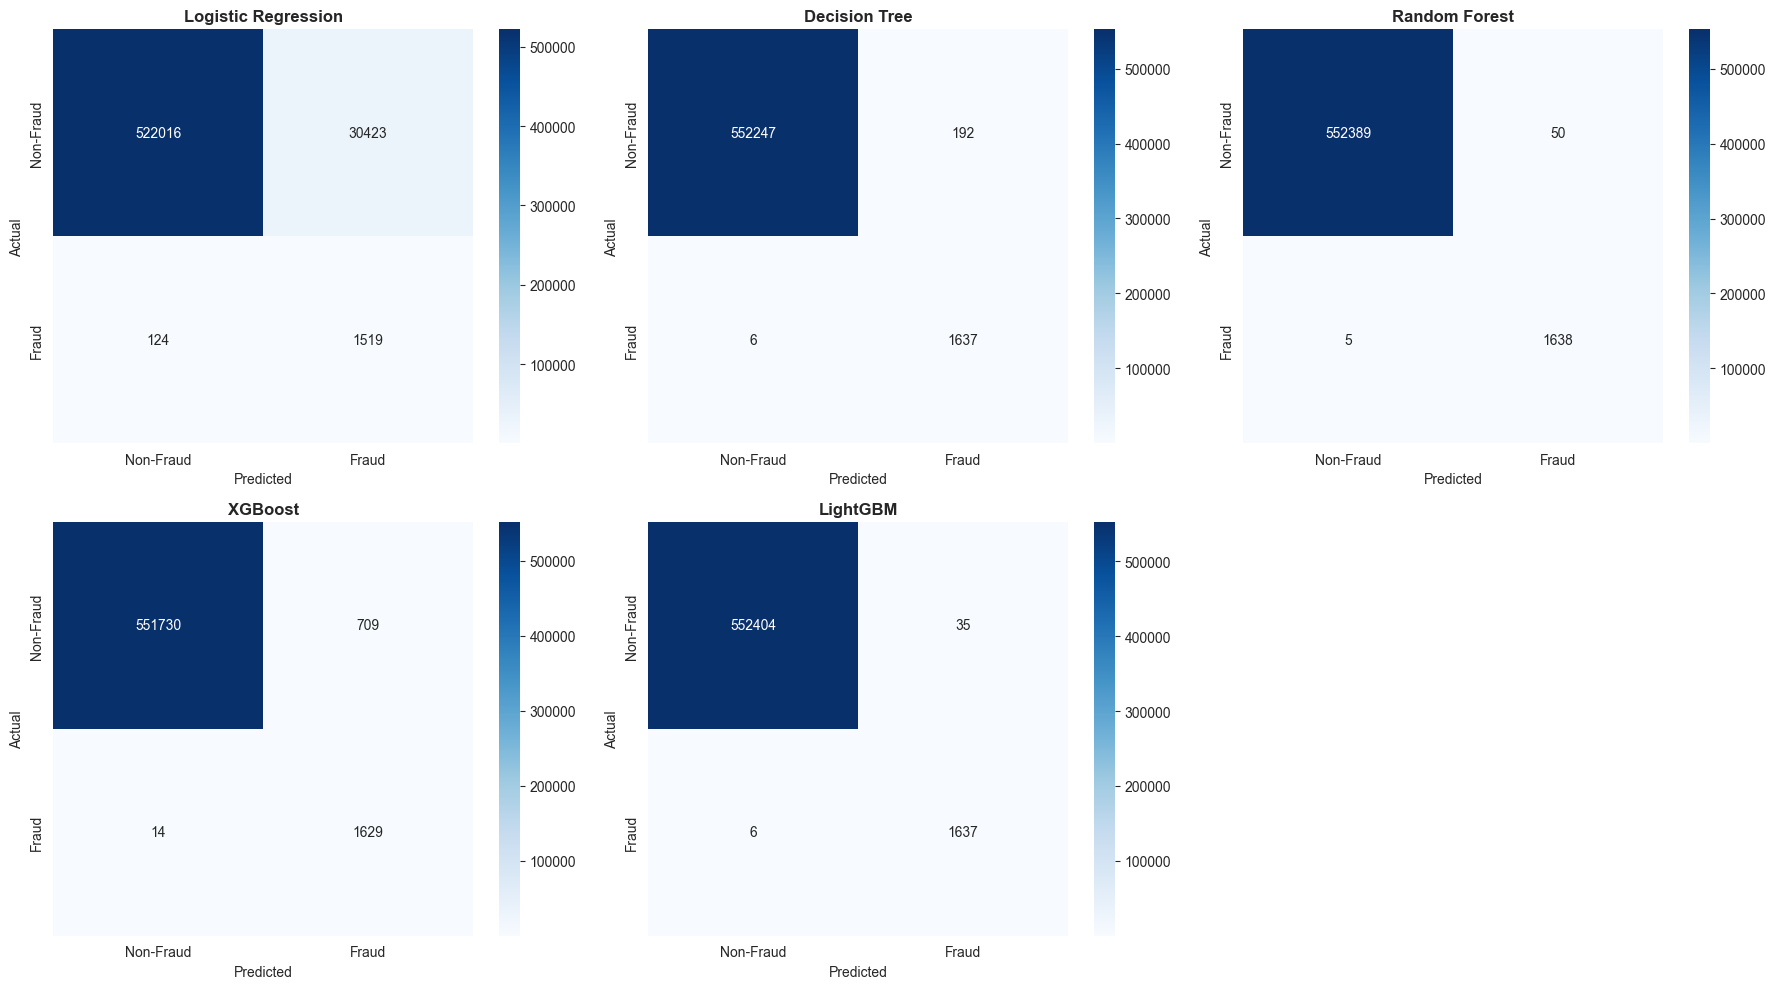

In [19]:
# ============================================================================
# STEP 12: CONFUSION MATRIX VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("CONFUSION MATRIX VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = results[model_name]['Predictions']
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)

# Hide the last subplot if odd number of models
if len(models) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()



ROC CURVE ANALYSIS


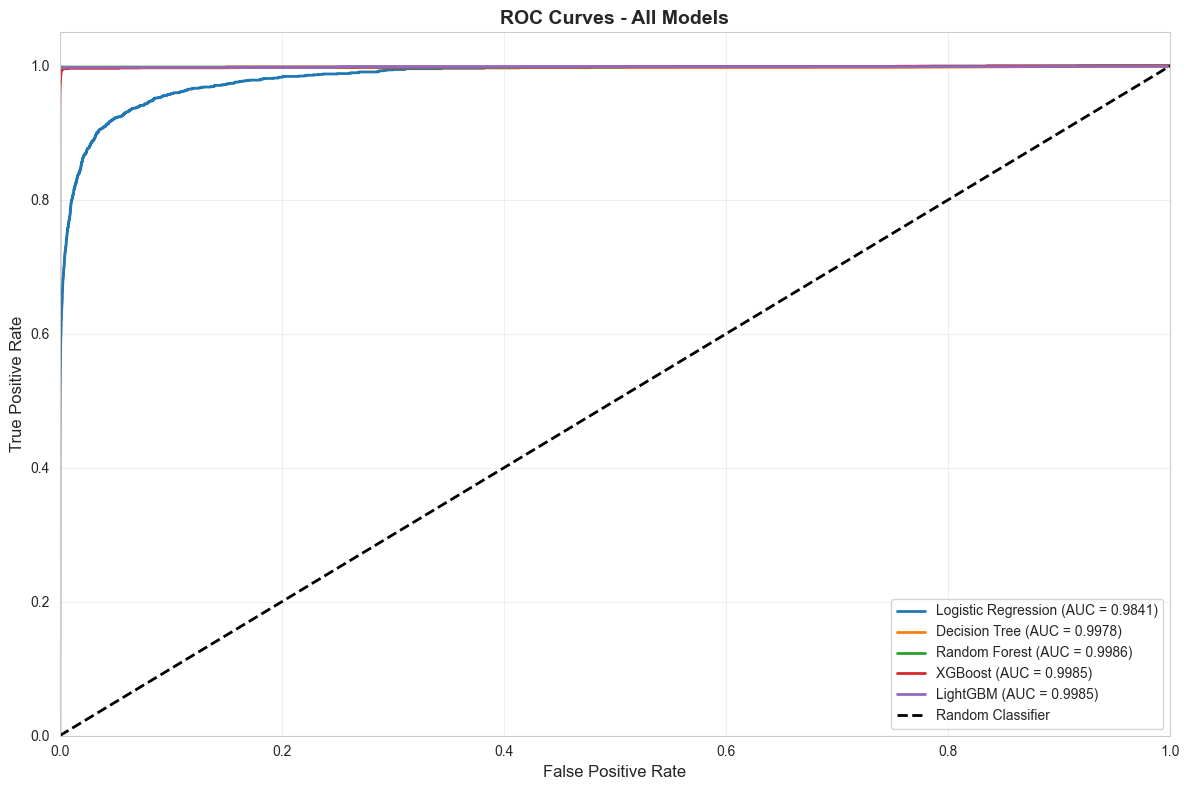

In [20]:
# ============================================================================
# STEP 13: ROC CURVE
# ============================================================================

print("\n" + "="*80)
print("ROC CURVE ANALYSIS")
print("="*80)

plt.figure(figsize=(12, 8))

for model_name in models.keys():
    y_pred_proba = results[model_name]['Probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = results[model_name]['ROC-AUC']

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE ANALYSIS

Best Model: LightGBM
F1-Score: 0.9876

Top 10 Most Important Features:
         Feature  Importance
            hour         497
destBalanceError         382
  oldbalanceDest         278
             day         273
  newbalanceDest         192
  newbalanceOrig         187
            step         187
   oldbalanceOrg         154
          amount         153
 destBalanceDiff         149


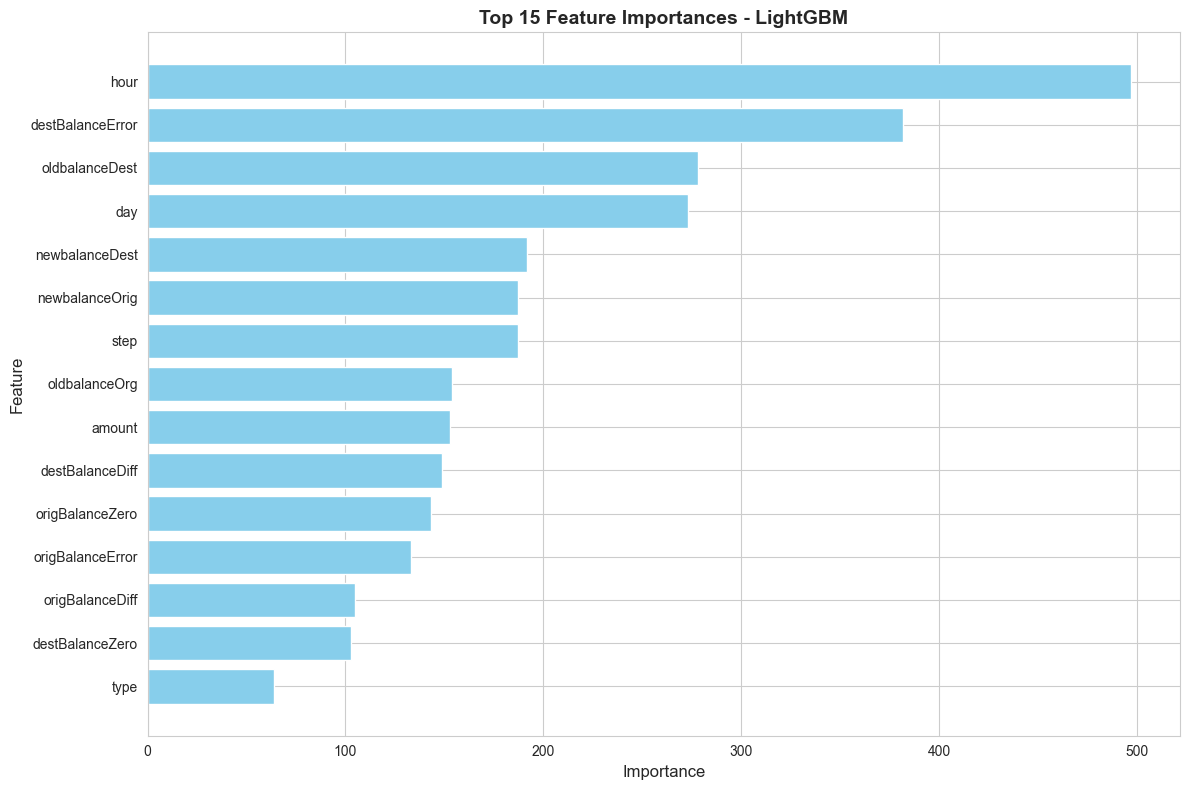

In [21]:
# ============================================================================
# STEP 14: FEATURE IMPORTANCE (Best Model)
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get best model based on F1-Score
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    # Visualize
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_model_name}',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================================
# STEP 15: SAVE BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("MODEL SAVING")
print("="*80)

import pickle

# Save the best model
model_filename = f'best_fraud_detection_model_{best_model_name.replace(" ", "_")}.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Save the scaler
scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

# Save label encoder
encoder_filename = 'label_encoder.pkl'
with open(encoder_filename, 'wb') as file:
    pickle.dump(label_encoder, file)

print(f"✅ Best model saved as: {model_filename}")
print(f"✅ Scaler saved as: {scaler_filename}")
print(f"✅ Label encoder saved as: {encoder_filename}")


MODEL SAVING
✅ Best model saved as: best_fraud_detection_model_LightGBM.pkl
✅ Scaler saved as: scaler.pkl
✅ Label encoder saved as: label_encoder.pkl


In [24]:
# ============================================================================
# STEP 16: PREDICTION FUNCTION FOR NEW TRANSACTIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING PREDICTION FUNCTION")
print("="*80)

def predict_fraud(transaction_data, model, scaler):
    """
    Predict if a transaction is fraudulent

    Parameters:
    transaction_data: dict or DataFrame with transaction details
    model: trained model
    scaler: fitted scaler

    Returns:
    prediction, probability
    """
    # Convert to DataFrame if dict
    if isinstance(transaction_data, dict):
        transaction_data = pd.DataFrame([transaction_data])

    # Scale features
    transaction_scaled = scaler.transform(transaction_data)

    # Predict
    prediction = model.predict(transaction_scaled)[0]
    probability = model.predict_proba(transaction_scaled)[0][1]

    result = "FRAUD" if prediction == 1 else "LEGITIMATE"

    return result, probability

# Example prediction
print("\nExample Prediction:")
sample_transaction = X_test.iloc[0:1]
result, prob = predict_fraud(sample_transaction, best_model, scaler)
print(f"Transaction Result: {result}")
print(f"Fraud Probability: {prob:.4f}")
print(f"Actual Label: {'FRAUD' if y_test.iloc[0] == 1 else 'LEGITIMATE'}")


CREATING PREDICTION FUNCTION

Example Prediction:
Transaction Result: LEGITIMATE
Fraud Probability: 0.0001
Actual Label: LEGITIMATE


In [25]:
# ============================================================================
# STEP 17: CUSTOM TEST CASES - REAL-WORLD SCENARIOS
# ============================================================================

print("\n" + "="*80)
print("TESTING WITH CUSTOM TRANSACTIONS")
print("="*80)

# Get feature names to ensure correct order
feature_names = X.columns.tolist()
print(f"\nRequired features: {feature_names}\n")

# Custom Test Case 1: SUSPICIOUS - Large transfer to new account
print("="*60)
print("TEST CASE 1: SUSPICIOUS TRANSACTION")
print("="*60)
print("Scenario: Large transfer ($500,000) to a brand new account (zero balance)")

custom_transaction_1 = {
    'step': 200,
    'type': 1,  # TRANSFER (encoded: 0=CASH_OUT, 1=TRANSFER)
    'amount': 500000,
    'oldbalanceOrg': 600000,
    'newbalanceOrig': 100000,
    'oldbalanceDest': 0,  # Suspicious: New account with zero balance
    'newbalanceDest': 500000,
    'origBalanceDiff': 500000,
    'destBalanceDiff': -500000,
    'origBalanceError': 0,
    'destBalanceError': 0,
    'origBalanceZero': 0,
    'destBalanceZero': 1,  # Flag: Destination had zero balance
    'day': 8,
    'hour': 3  # Late night transaction
}

result_1, prob_1 = predict_fraud(custom_transaction_1, best_model, scaler)
print(f"\n🔍 Prediction: {result_1}")
print(f"📊 Fraud Probability: {prob_1:.2%}")
if result_1 == "FRAUD":
    print("🚨 ACTION: BLOCK TRANSACTION - High fraud risk detected!")
else:
    print("✅ ACTION: Transaction appears legitimate")

# Custom Test Case 2: LEGITIMATE - Normal transfer
print("\n" + "="*60)
print("TEST CASE 2: LEGITIMATE TRANSACTION")
print("="*60)
print("Scenario: Small transfer ($5,000) between established accounts")

custom_transaction_2 = {
    'step': 150,
    'type': 1,  # TRANSFER
    'amount': 5000,
    'oldbalanceOrg': 50000,
    'newbalanceOrig': 45000,
    'oldbalanceDest': 30000,  # Established account with balance
    'newbalanceDest': 35000,
    'origBalanceDiff': 5000,
    'destBalanceDiff': -5000,
    'origBalanceError': 0,
    'destBalanceError': 0,
    'origBalanceZero': 0,
    'destBalanceZero': 0,  # Both accounts have balances
    'day': 5,
    'hour': 14  # Afternoon transaction
}

result_2, prob_2 = predict_fraud(custom_transaction_2, best_model, scaler)
print(f"\n🔍 Prediction: {result_2}")
print(f"📊 Fraud Probability: {prob_2:.2%}")
if result_2 == "FRAUD":
    print("🚨 ACTION: BLOCK TRANSACTION - High fraud risk detected!")
else:
    print("✅ ACTION: Transaction appears legitimate")

# Custom Test Case 3: HIGHLY SUSPICIOUS - Balance mismatch
print("\n" + "="*60)
print("TEST CASE 3: HIGHLY SUSPICIOUS - BALANCE ANOMALY")
print("="*60)
print("Scenario: Transfer with balance error (amount doesn't match balance change)")

custom_transaction_3 = {
    'step': 300,
    'type': 0,  # CASH_OUT
    'amount': 200000,
    'oldbalanceOrg': 250000,
    'newbalanceOrig': 0,  # Account emptied
    'oldbalanceDest': 0,
    'newbalanceDest': 0,  # Suspicious: Money disappeared
    'origBalanceDiff': 250000,  # More than transaction amount
    'destBalanceDiff': 0,
    'origBalanceError': -50000,  # ERROR: Balance change doesn't match amount
    'destBalanceError': 200000,  # ERROR: Destination balance anomaly
    'origBalanceZero': 0,
    'destBalanceZero': 1,
    'day': 12,
    'hour': 2  # Very late night
}

result_3, prob_3 = predict_fraud(custom_transaction_3, best_model, scaler)
print(f"\n🔍 Prediction: {result_3}")
print(f"📊 Fraud Probability: {prob_3:.2%}")
if result_3 == "FRAUD":
    print("🚨 ACTION: BLOCK TRANSACTION - High fraud risk detected!")
else:
    print("✅ ACTION: Transaction appears legitimate")

# Custom Test Case 4: Your own case - Modify as needed
print("\n" + "="*60)
print("TEST CASE 4: CREATE YOUR OWN SCENARIO")
print("="*60)
print("Scenario: Medium cash-out from established account")

custom_transaction_4 = {
    'step': 100,
    'type': 0,  # CASH_OUT
    'amount': 75000,
    'oldbalanceOrg': 150000,
    'newbalanceOrig': 75000,
    'oldbalanceDest': 50000,
    'newbalanceDest': 125000,
    'origBalanceDiff': 75000,
    'destBalanceDiff': -75000,
    'origBalanceError': 0,
    'destBalanceError': 0,
    'origBalanceZero': 0,
    'destBalanceZero': 0,
    'day': 4,
    'hour': 10  # Morning transaction
}

result_4, prob_4 = predict_fraud(custom_transaction_4, best_model, scaler)
print(f"\n🔍 Prediction: {result_4}")
print(f"📊 Fraud Probability: {prob_4:.2%}")
if result_4 == "FRAUD":
    print("🚨 ACTION: BLOCK TRANSACTION - High fraud risk detected!")
else:
    print("✅ ACTION: Transaction appears legitimate")

# Summary of all custom tests
print("\n" + "="*80)
print("CUSTOM TEST SUMMARY")
print("="*80)

summary_df = pd.DataFrame({
    'Test Case': ['Case 1: Suspicious Transfer', 'Case 2: Legitimate Transfer',
                  'Case 3: Balance Anomaly', 'Case 4: Custom Case'],
    'Amount': [500000, 5000, 200000, 75000],
    'Prediction': [result_1, result_2, result_3, result_4],
    'Probability': [f'{prob_1:.2%}', f'{prob_2:.2%}', f'{prob_3:.2%}', f'{prob_4:.2%}']
})

print("\n", summary_df.to_string(index=False))

print("\n" + "="*80)
print("💡 TIP: Modify the custom_transaction_4 values above to test your own scenarios!")
print("="*80)



TESTING WITH CUSTOM TRANSACTIONS

Required features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'origBalanceDiff', 'destBalanceDiff', 'origBalanceError', 'destBalanceError', 'origBalanceZero', 'destBalanceZero', 'day', 'hour']

TEST CASE 1: SUSPICIOUS TRANSACTION
Scenario: Large transfer ($500,000) to a brand new account (zero balance)

🔍 Prediction: LEGITIMATE
📊 Fraud Probability: 0.01%
✅ ACTION: Transaction appears legitimate

TEST CASE 2: LEGITIMATE TRANSACTION
Scenario: Small transfer ($5,000) between established accounts

🔍 Prediction: LEGITIMATE
📊 Fraud Probability: 0.00%
✅ ACTION: Transaction appears legitimate

TEST CASE 3: HIGHLY SUSPICIOUS - BALANCE ANOMALY
Scenario: Transfer with balance error (amount doesn't match balance change)

🔍 Prediction: FRAUD
📊 Fraud Probability: 99.99%
🚨 ACTION: BLOCK TRANSACTION - High fraud risk detected!

TEST CASE 4: CREATE YOUR OWN SCENARIO
Scenario: Medium cash-out from established accou